In [105]:
# Setup and package imports 
import mlflow
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder,
    VectorAssembler, MinMaxScaler
)

from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics
 

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 3, Finished, Available, Finished, False)

In [106]:
from pyspark.sql import functions as F
# --------------------------------------------
# a. Read Dataset and create Spark DataFrame -
# --------------------------------------------


spark_df = spark.read.table('FraudDetection.dbo.silver_data_for_MLmodel') #.select(features)

ratio = 43956 / 27470

spark_df = spark_df.withColumn(
    
    "weight",
    F.when(spark_df.isFraud == 1, ratio).otherwise(1.0)
)
display( spark_df )

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 5, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 153587d9-d8fa-4f3b-9330-9bf2325f9366)

In [13]:

fraud_df = spark_df.filter("isFraud = 1")
non_fraud_df = spark_df.filter("isFraud = 0")

on_fraud_sample = non_fraud_df.sample(fraction=0.01)
balanced_df = fraud_df.union(fraud_df)

StatementMeta(, 3aabdfc2-b40f-4ee6-b2a4-53e811d6ba6d, 20, Finished, Available, Finished, False)

In [98]:
spark_df.groupBy('isFraud').count().show()

StatementMeta(, 3d262e03-ff6d-4d57-a052-2829d2492c93, 235, Finished, Available, Finished, False)

+-------+-------+
|isFraud|  count|
+-------+-------+
|      0|2099293|
|      1|  27470|
+-------+-------+



In [107]:
# ** 4. Train / Test Split **
train_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=42)


#fractions = {0: 0.8, 1: 0.8}  # keep proportions

#train_df = spark_df.stat.sampleBy("isFraud", fractions=fractions, seed=42)

#test_df = spark_df.subtract(train_df)


StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 6, Finished, Available, Finished, False)

In [88]:
display(spark_df.groupBy('isFraud').count().show())

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 7, Finished, Available, Finished, False)

+-------+-----+
|isFraud|count|
+-------+-----+
|      0|44103|
|      1|27470|
+-------+-----+



In [108]:
%run /ml_common

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 13, Finished, Available, Finished, True)

In [26]:

#max_depth = trial.suggest_int("max_depth", 5, 20)
#max_bins = trial.suggest_categorical("max_bins",[10, 20, 30])
#num_trees = trial.suggest_categorical("numTrees", [50, 100, 150])


#with mlflow.start_run(nested=True):
# Train a model using the provided hyperparameter value
#numericalFeatures = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
#assembler = VectorAssembler(inputCols=numericalFeatures, outputCol="numericFeatures") # Numerical verctorized data
#scaler = MinMaxScaler(inputCol=assembler.getOutputCol(), outputCol="normalizedFeatures")
#featureVector = VectorAssembler(inputCols=["normalizedFeatures"], outputCol="features")

# -----------------------------------------
# 0. Get categorical and numerical features
# --------------------------------------------
label_col = "isFraud" 
categorical_cols, numeric_cols = auto_detect_colum_type(spark_df, label_col)

# **1. Preprocessing the pipeline** 
# ---------------------------------------
# 1.1 Encode categorical freatures 
# --------------------------------------
#indexers, encoders = encode_categorical_features(categorical_cols)
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    )
    for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_ohe"
    )
    for c in categorical_cols
]

# -------------------------------------------------------
# 1.2 Assemble features 
# ----------------------------
assembler_inputs = [f"{c}_idx" for c in categorical_cols] + numeric_cols
print('Assembler Inputs: ', assembler_inputs)

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw"
)

# ----------------------------
# 1.3 Scaling: MimMax scaling 
# ----------------------------
scaler = MinMaxScaler(
    inputCol="features_raw",
    outputCol="features"
)
 
    
dtAlgo = RandomForestClassifier(
    labelCol=label_col,
    featuresCol="features_raw" 

) #DecisionTreeClassifier(labelCol=label_col, featuresCol="features", maxDepth=max_depth, maxBins=max_bins)

pipeline = Pipeline(stages=[*indexers,  assembler, dtAlgo]) # Pipeline

# ** 4. Hyperparamer tunning: for  **
paramGrid = hyperparameter_tunning(dtAlgo, 'RandomForest')

# ** 5. Evaluate and validate the model **
evaluator, cv = evaluate_and_validate(label_col, pipeline, paramGrid)
    
"""model = pipeline.fit(train_df)

    # Evaluate the model
    predictions = model.transform(test_df)

    eval = BinaryClassificationEvaluator(labelCol=label_col, metricName="areaUnderROC")
    accuracy_score = eval.evaluate(predictions)

    # Log parameters and metrics
    mlflow.log_param('MaxDepth', max_depth)
    mlflow.log_param('MaxBins', max_bins)
    mlflow.log_metric('accuracy', accuracy_score)


    ## Infer and log model signiture
    #signature = infer_signature(train_df.select(numericalFeatures).toPandas(), predictions.select('prediction').toPandas())
    #mlflow.spark.log_model(model, "model", signature=signature, dfs_tmpdir='/Volumes/mlpractice/source/mlmodel/ml_lab/tmp/')
    
  return accuracy_score """

StatementMeta(, 3d262e03-ff6d-4d57-a052-2829d2492c93, 39, Finished, Available, Finished, False)

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']
Assembler Inputs:  ['type_idx', 'orig_name_type_idx', 'dest_name_type_idx', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


'model = pipeline.fit(train_df)\n\n    # Evaluate the model\n    predictions = model.transform(test_df)\n\n    eval = BinaryClassificationEvaluator(labelCol=label_col, metricName="areaUnderROC")\n    accuracy_score = eval.evaluate(predictions)\n\n    # Log parameters and metrics\n    mlflow.log_param(\'MaxDepth\', max_depth)\n    mlflow.log_param(\'MaxBins\', max_bins)\n    mlflow.log_metric(\'accuracy\', accuracy_score)\n\n\n    ## Infer and log model signiture\n    #signature = infer_signature(train_df.select(numericalFeatures).toPandas(), predictions.select(\'prediction\').toPandas())\n    #mlflow.spark.log_model(model, "model", signature=signature, dfs_tmpdir=\'/Volumes/mlpractice/source/mlmodel/ml_lab/tmp/\')\n    \n  return accuracy_score '

In [32]:
# -----------------------------------
# 4. MLflow tracking (Fabric auto-integrated)
# -----------------------------------
mlflow.set_experiment("fabric_spark_RFClassifier")

with mlflow.start_run():

    model = cv.fit(train_df)

    best_model = model.bestModel

    # Log best params manually
    best_lr = best_model.stages[-1]
    

    #mlflow.log_param("maxDepth", best_lr.getMaxDepth())
    #mlflow.log_param("maxIter", best_lr.getNumTrees())
    #mlflow.log_param("maxBins", best_lr.getMaxBins())

    # Evaluate
    preds = best_model.transform(test_df)
    auc = evaluator.evaluate(preds)

    mlflow.log_metric("AUC", auc)

    print("Best AUC:", auc)

StatementMeta(, 3d262e03-ff6d-4d57-a052-2829d2492c93, 45, Finished, Cancelled, Cancelled, False)

In [117]:
mlflow.end_run()

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 14, Finished, Available, Finished, False)

In [111]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from pyspark.mllib.evaluation import BinaryClassificationMetrics

def decitionTree_model_experment(trial, train_df, test_df):

    """max_depth = trial.suggest_int("max_depth", 10, 30)
    max_bins = trial.suggest_categorical("max_bins",[20, 30, 50])
    num_trees = trial.suggest_categorical("numTrees", [100, 150, 200])"""

    max_depth = trial.suggest_int("maxDepth", 5, 20)
    max_bins = trial.suggest_categorical("maxBins", [32, 64, 128])
    num_trees = trial.suggest_int("numTrees", 200, 800)
    min_instances = trial.suggest_int("minInstancesPerNode", 1, 20)
    subsampling_rate = trial.suggest_float("subsamplingRate", 0.5, 1.0)

    feature_subset = trial.suggest_categorical(
        "featureSubsetStrategy",
        ["sqrt", "log2", "0.5", "0.8"]
    )

    with mlflow.start_run(nested=True):

        label_col = "isFraud" 
        
        categorical_cols, numeric_cols = auto_detect_colum_type(train_df, label_col)

        # ----------------------------
        # 1. Encoding
        # ----------------------------
        indexers = [
            StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
            for c in categorical_cols
        ]

        # ----------------------------
        # 2. Assemble features
        # ----------------------------
        assembler_inputs = [f"{c}_idx" for c in categorical_cols] + numeric_cols

        assembler = VectorAssembler(
            inputCols=assembler_inputs,
            outputCol="features"
        )

        # ----------------------------
        # 3. Model
        # ----------------------------
        rf = RandomForestClassifier(
            labelCol=label_col,
            featuresCol="features",
            numTrees=num_trees,
            maxDepth=max_depth,
            maxBins=max_bins,
            weightCol='weight'
        )

        pipeline = Pipeline(stages=[*indexers, assembler, rf])

        # ----------------------------
        # 4. Train
        # ----------------------------
        model = pipeline.fit(train_df)

        # ----------------------------
        # 5. Predict
        # ----------------------------
        predictions = model.transform(test_df)

        # ----------------------------
        # 6. AUC
        # ----------------------------
        evaluator = BinaryClassificationEvaluator(
            labelCol=label_col,
            rawPredictionCol="rawPrediction",
            metricName="areaUnderROC"
        )

        auc = evaluator.evaluate(predictions)

        # ----------------------------
        # ✅ 7. ROC Curve Data
        # ----------------------------
        # Extract (score, label)
        """scoreAndLabels = predictions.select("rawPrediction", label_col) \
            .rdd.map(lambda row: (float(row["rawPrediction"][1]), float(row[label_col])))

        metrics = BinaryClassificationMetrics(scoreAndLabels)

        roc = metrics.roc().collect()

        fpr = [x[0] for x in roc]
        tpr = [x[1] for x in roc]"""

        preds_pd = predictions.toPandas()[["isFraud", "probability"]]
        preds_pd["prob"] = preds_pd["probability"].apply(lambda x: x[1])

        # ----------------------------
        # ✅ 8. Plot ROC Curve
        # ----------------------------
        fpr, tpr, thresholds = roc_curve(preds_pd["isFraud"], preds_pd["prob"])
        #roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
        plt.plot([0, 1], [0, 1], linestyle="--")

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()

        plt.show()

        # ----------------------------
        # 9. Log
        # ----------------------------
        mlflow.log_param("max_depth", max_depth)
        mlflow.log_param("max_bins", max_bins)
        mlflow.log_param("numTrees", num_trees)
        mlflow.log_metric("AUC", auc)

    return auc


StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 22, Finished, Available, Finished, False)

StatementMeta(, b7844578-a9eb-43a1-bede-14a868cd3199, 24, Finished, Available, Finished, False)

[I 2026-06-03 07:01:41,691] A new study created in memory with name: diabetes_classification_without_scleing


Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


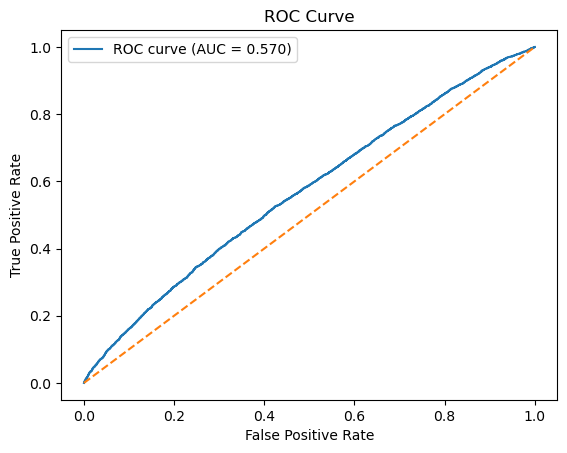

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


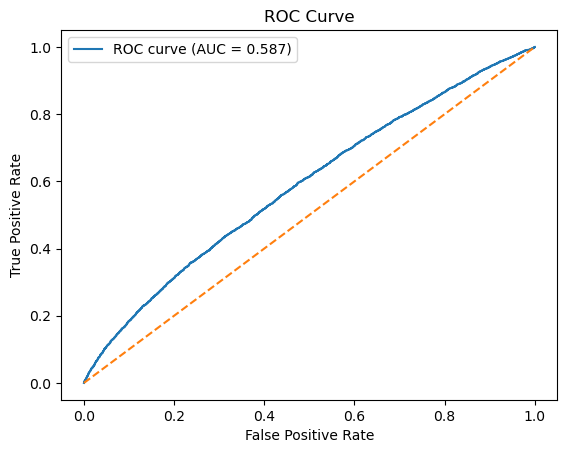

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


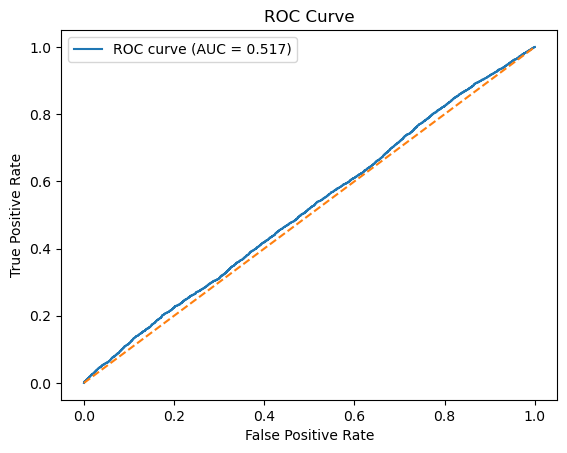

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


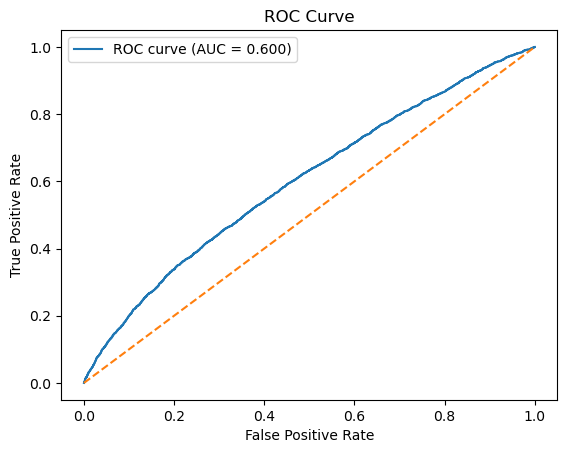

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq']


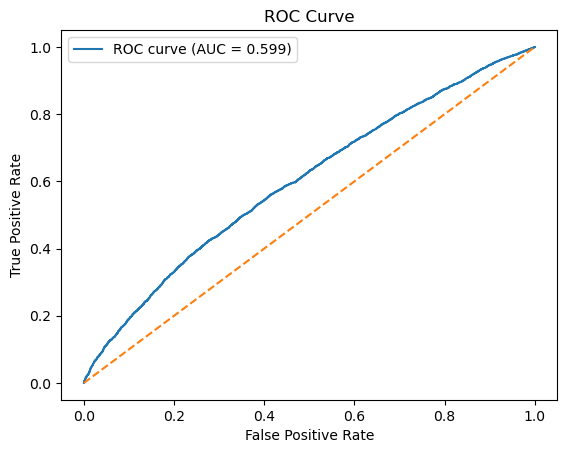

Best param vales:  {'maxDepth': 18, 'maxBins': 128, 'numTrees': 787, 'minInstancesPerNode': 7, 'subsamplingRate': 0.676727716514271, 'featureSubsetStrategy': '0.5'}
Best accuracy:  0.6000522334245485

 All trials:

Trail -> number:  0, params: {'maxDepth': 14, 'maxBins': 64, 'numTrees': 383, 'minInstancesPerNode': 10, 'subsamplingRate': 0.9031278005174322, 'featureSubsetStrategy': '0.8'}, accuracy: 0.5695524687776637

Trail -> number:  1, params: {'maxDepth': 18, 'maxBins': 64, 'numTrees': 267, 'minInstancesPerNode': 2, 'subsamplingRate': 0.8804084201787787, 'featureSubsetStrategy': '0.5'}, accuracy: 0.5869354594321524

Trail -> number:  2, params: {'maxDepth': 7, 'maxBins': 64, 'numTrees': 264, 'minInstancesPerNode': 20, 'subsamplingRate': 0.8365549091686472, 'featureSubsetStrategy': 'log2'}, accuracy: 0.5169448987821842

Trail -> number:  3, params: {'maxDepth': 18, 'maxBins': 128, 'numTrees': 787, 'minInstancesPerNode': 7, 'subsamplingRate': 0.676727716514271, 'featureSubsetStrategy

In [112]:
# Defining the Search Space for hyperparameters, and log each hyperparamer run using a Trials() object

import optuna
#from optuna.integration.mlflow import MlflowCallback

# Create the optuna study to maximize accuracy
with mlflow.start_run(run_name="DecisionTreeClassifier_Optuna"):
    study = optuna.create_study(direction="maximize", study_name='diabetes_classification_without_scleing')

    # run optimization
    study.optimize(lambda trial: decitionTree_model_experment(trial, train_df, test_df), n_trials=5)

    # Get best parametes 
    print("Best param vales: ", study.best_params)
    print("Best accuracy: ", study.best_value)

    # Log best params to parent run
    mlflow.log_params(study.best_params)
    mlflow.log_metric('best_accuracy', study.best_value )

    # display all trails
    print('\n All trials:')
    for trial in study.trials:
        print(f'\nTrail -> number:  {trial.number}, params: {trial.params}, accuracy: {trial.value}')

 

In [5]:
preds_pd = preds.toPandas()[["isFraud", "probability"]]
preds_pd["prob"] = preds_pd["probability"].apply(lambda x: x[1])
#preds_pd = preds_pd.drop(["probability"], axis=1

display(preds_pd)

StatementMeta(, 3d262e03-ff6d-4d57-a052-2829d2492c93, 9, Finished, Available, Finished, False)

NameError: name 'preds' is not defined

In [4]:
# ROC curve plot

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(preds_pd["isFraud"], preds_pd["prob"])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

StatementMeta(, 3d262e03-ff6d-4d57-a052-2829d2492c93, 7, Finished, Available, Finished, False)

NameError: name 'preds_pd' is not defined